# Example: Building a Minimum-Variance Portfolio with Hybrid Forward Simulation

In this example, we assemble a minimum-variance portfolio from a user-chosen ticker list by loading the SIM parameters calibrated in the previous notebook, building the SIM covariance matrix on that subset, tracing the efficient frontier, and then forward-simulating the chosen allocation with the hybrid [JumpHMM](https://github.com/varnerlab/JumpHMM.jl) construction. We hold the allocation buy-and-hold over the horizon across many synthetic futures and summarize the outcome as a distributional scorecard.

> __Learning Objectives:__
>
> * __Calibrated SIM portfolios:__ We load pre-computed SIM regression parameters for a user-chosen ticker subset from the S&P 500 calibration and build the SIM covariance matrix and expected growth rate vector on that subset. We solve the minimum-variance allocation problem at a target return and trace the full efficient frontier to see how the risk-return trade-off evolves.
> * __Hybrid forward simulation with regime structure:__ We compose synthetic market futures from a regime-switching market model, per-ticker idiosyncratic draws, and a Student-t copula that enforces realistic cross-sectional dependence. The resulting scenarios carry fat tails, volatility clustering, and regime shifts that a Gaussian Single Index Model cannot reproduce.
> * __Distributional scorecard replaces point estimates:__ We hold the chosen allocation buy-and-hold across every simulated path and summarize the outcome distribution through median terminal wealth, percentile spreads, maximum drawdown, Sharpe ratio, and two failure rates. Portfolio quality is judged as a full distribution over synthetic futures rather than a single point estimate.

Let's get started!
___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via the `Include.jl` file. This activates the local Julia environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Constants
In the section below, we set some constants that will be used throughout the notebook. These include the list of tickers to consider, the target return for the minimum-variance portfolio, and the number of forward-simulation paths to generate, etc. We can modify these constants to explore different scenarios and allocations. 

See the comments in the code for more details on each constant, its purpose, units, etc.

In [2]:
# --- Portfolio universe ---
# Load the ticker universe from data/my-tickers.csv. To change the universe,
# edit that file directly (see lets_find_my_tickers.md for the procedure).
# Every ticker must exist in MySIMCalibration()["tickers"].
tickers_df = CSV.read(joinpath(_PATH_TO_DATA, "my-tickers.csv"), DataFrame); # ticker,sector rows
my_tickers = String.(tickers_df.ticker);                                     # Vector{String} of tickers (length N)
N          = nrow(tickers_df);                                               # number of tickers in the universe

# --- Portfolio configuration ---
# Load budget, risk-free rate, target growth, and concentration cap from portfolio-config.toml.
cfg        = TOML.parsefile(joinpath(_PATH_TO_DATA, "portfolio-config.toml"));         # parsed TOML as nested Dict
B₀         = Float64(cfg["portfolio"]["initial_budget"]);                              # initial wealth W₀ (USD)
g_f        = Float64(cfg["portfolio"]["risk_free_rate"]);                              # risk-free growth rate g_f (continuous compounding, 1/yr); NPV baseline
R_target   = Float64(cfg["portfolio"]["target_growth"]);                               # QP return constraint: μᵀ w ≥ R_target (1/yr, CCGR)
max_weight = Float64(get(cfg["portfolio"], "max_weight", 1.0));                        # per-ticker upper bound w_i ≤ max_weight (concentration cap)
@assert max_weight >= 1.0/N "max_weight = $(max_weight) is infeasible for N = $(N) tickers (need >= $(round(1/N, digits=3)))"

# --- Forward simulation parameters ---
n_paths  = 500;            # number of Monte Carlo paths generated by generate_hybrid_scenario
n_steps  = 252;            # forward horizon in trading days (≈ 1 calendar year)
Δt       = 1.0 / 252.0;    # daily time step in years; used for annualization (e.g. Sharpe × √(1/Δt))

# --- Optional custom allocation override ---
# Leave as nothing to use the minimum-variance QP weights at R_target.
# Set to a Vector{Float64} of length N that sums to 1 to override.
my_weights = nothing;       # nothing = use QP solution; else user-supplied weights passed to backtest_buyhold

println("Universe: $(N) tickers loaded from my-tickers.csv")
println("  $(my_tickers)")
println("Budget: \$$(Int(B₀))")
println("Horizon: $(n_steps) days, $(n_paths) Monte Carlo paths, R_target = $(round(R_target*100, digits=1))%/yr")
println("Risk-free baseline: $(round(g_f*100, digits=2))%/yr (continuous compounding)")
println("Concentration cap: max_weight = $(round(max_weight*100, digits=1))% per ticker")

Universe: 20 tickers loaded from my-tickers.csv
  ["VZ", "T", "MCD", "PG", "KO", "PEP", "WMT", "XOM", "CVX", "JPM", "BRK.B", "JNJ", "MRK", "HON", "UPS", "AAPL", "MSFT", "APD", "AMT", "NEE"]
Budget: $100000
Horizon: 252 days, 500 Monte Carlo paths, R_target = 7.0%/yr
Risk-free baseline: 4.5%/yr (continuous compounding)
Concentration cap: max_weight = 20.0% per ticker


___
## Task 1: Build the Minimum-Variance Portfolio from Calibrated SIM
In this task, we pick a small ticker subset, load the SIM parameters calibrated in the [SIM parameter estimation notebook](eCornell-AI-Finance-S1-Example-SIMParameterEstimation-May-2026.ipynb), assemble the SIM covariance matrix, solve the minimum-variance QP at our chosen target return, sweep the frontier, and resolve the final allocation that we will forward-simulate in Task 2.

> __What are we going to do?__
>
> Task 1 runs the pipeline from calibrated SIM parameters to a resolved weight vector.
>
> * __Load and extract:__ Pull $\alpha_i$, $\beta_i$, and $\sigma_{\varepsilon,i}$ for `my_tickers` from the cached SIM calibration via [the `MySIMCalibration()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySIMCalibration). All quantities are in annualized growth-rate units (1/year): $\alpha$ is a per-year drift, $\sigma_\varepsilon$ is the annualized residual standard deviation, and $\sigma_m$ is the sample standard deviation of SPY's annualized growth rates.
> * __Build and solve:__ Assemble the SIM covariance matrix $\Sigma$ with [the `build_sim_covariance(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.build_sim_covariance) and solve the minimum-variance QP at target return $R^{*}$ with [the `solve_minvariance(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.solve_minvariance).
> * __Sweep and resolve:__ Sweep the target return $R$ to trace the efficient frontier, then pull the chosen weights into `allocation_weights::Vector{Float64}`. The `my_weights = nothing` slot lets us override the QP solution with a custom vector for non-optimal stress tests.
>
> The calibration itself was fitted from 2014 to 2024 VWAP data by regressing each ticker's annualized growth rate on SPY.

In the code block below, we load the calibration, extract the subset for `my_tickers`, and bind three values the rest of the notebook uses: `sim_estimates::Vector{MySIMParameterEstimate}` (one estimate per ticker, in `my_tickers` order), `σ_m::Float64` (sample standard deviation of SPY's annualized growth rates, 1/yr), and `sim_calibration::Dict{String,Any}` (the full calibration dictionary, retained for downstream scenario generation).

In [3]:
sim_estimates, σ_m, sim_calibration = let

    # --- Step 1: Load the SIM parameter estimates (saved by the SIM notebook) ---
    sim_data = load_results(joinpath(_PATH_TO_DATA, "sim-parameter-estimates.jld2"));
    all_estimates = sim_data["sim_estimates"];
    est_lookup = Dict{String, MySIMParameterEstimate}();
    for est ∈ all_estimates
        est_lookup[est.ticker] = est;
    end

    # --- Step 2: Validate that every user ticker is present ---
    missing = [t for t ∈ my_tickers if !haskey(est_lookup, t)];
    @assert isempty(missing) "Tickers not in SIM estimates: $(missing)"

    # --- Step 3: Extract the subset for our universe ---
    estimates = [est_lookup[t] for t ∈ my_tickers];

    # --- Step 4: Market volatility ---
    σm = sim_data["sigma_market"];

    # --- Step 5: Display the calibrated parameters for the subset ---
    df = DataFrame(
        "Ticker" => [e.ticker for e ∈ estimates],
        "α (%/yr)" => [round(e.α * 100, digits=2) for e ∈ estimates],
        "β" => [round(e.β, digits=3) for e ∈ estimates],
        "σ_ε grow (%/yr)" => [round(e.σ_ε * 100, digits=1) for e ∈ estimates],
        "σ_ε vol (%/yr)"  => [round(e.σ_ε / sqrt(252) * 100, digits=2) for e ∈ estimates],
        "R²" => [round(e.r², digits=3) for e ∈ estimates]
    );
    println("SIM parameters for $(length(estimates)) tickers:")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
    println("Market σ_m (1/year): $(round(σm, digits=4))  "
            * "→ growth %/yr: $(round(σm*100, digits=1))%  "
            * "fin vol %/yr: $(round(σm/sqrt(252)*100, digits=2))%")

    estimates, σm, sim_data
end;

SIM parameters for 20 tickers:
 -------- ---------- --------- ----------------- ---------------- ---------
  Ticker   α (%/yr)         β   σ_ε grow (%/yr)   σ_ε vol (%/yr)        R² 
  String    Float64   Float64           Float64          Float64   Float64 
 -------- ---------- --------- ----------------- ---------------- ---------
      VZ      -6.51      0.45             281.8            17.75     0.199
       T     -10.58     0.629             339.8             21.4     0.251
     MCD       2.66      0.69             239.0            15.06     0.449
      PG        1.5     0.486             251.5            15.84     0.267
      KO      -2.74     0.626             242.5            15.28     0.394
     PEP      -0.22     0.543             269.1            16.95     0.285
     WMT       6.04     0.496             309.4            19.49       0.2
     XOM      -9.36     0.944             366.8            23.11     0.393
     CVX      -9.56     1.029             337.1            21.24 

The minimum-variance QP needs the vector of expected asset growth rates $\mathbb{E}[\mathbf{g}] = [\mathbb{E}[g_i]]$ with $\mathbb{E}[g_i] = \alpha_i + \beta_i \cdot \mathbb{E}[g_{\mathrm{mkt}}]$, where $\mathbb{E}[g_{\mathrm{mkt}}]$ is the expected market growth rate. In the code block below, we pull $\mathbb{E}[g_{\mathrm{mkt}}]$ from [the `MySyntheticTrainingDataSet()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySyntheticTrainingDataSet), which stores the mean of the frozen synthetic market path, and save both: `Eg_mkt::Float64` (expected market growth rate, annualized, 1/yr) and `Eg_vec::Vector{Float64}` (per-ticker SIM expected growth rates, same units, one entry per ticker in `my_tickers` order).

In [4]:
Eg_mkt, Eg_vec = let
    # --- Step 1: Expected market growth rate from the synthetic training dataset ---
    ds = MySyntheticTrainingDataSet();
    Egmkt = mean(ds["market_returns"]);      # 1/year

    # --- Step 2: SIM expected growth rate per ticker: E[g_i] = α_i + β_i · E[g_mkt] ---
    Eg = [est.α + est.β * Egmkt for est ∈ sim_estimates];

    println("E[g_mkt] (annualized market growth rate): $(round(Egmkt*100, digits=2))%/yr")
    println("E[g] range across user tickers: "
            * "[$(round(minimum(Eg)*100, digits=2))%, $(round(maximum(Eg)*100, digits=2))%]/yr")

    Egmkt, Eg
end;

E[g_mkt] (annualized market growth rate): 7.93%/yr
E[g] range across user tickers: [-5.59%, 20.08%]/yr


With the SIM parameters in hand we build the covariance matrix, solve the QP at the target return, and sweep `R` to trace the entire efficient frontier.

> __SIM Covariance Matrix:__
>
> [The `build_sim_covariance(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.build_sim_covariance) assembles the covariance of annualized growth rates directly from the SIM parameters in three moving parts.
>
> * __Off-diagonals (pure market co-movement):__ $\Sigma_{ij} = \beta_i \beta_j \sigma_m^2$ captures how much assets $i$ and $j$ move together through their shared exposure to the market factor.
> * __Diagonals (market plus idiosyncratic):__ $\Sigma_{ii} = \beta_i^2 \sigma_m^2 + \sigma_{\varepsilon,i}^2$ adds each asset's firm-specific residual variance on top of its market component. All entries are in $(1/\text{year})^2$.
> * __Structural payoff:__ The SIM covariance has only $N + 1$ free parameters ($N$ betas plus the market variance), not the $N(N+1)/2$ of a sample covariance. This keeps optimization tractable on large universes and avoids the noise that short-window sample covariances accumulate.
>
> With $\Sigma$ in hand we build the problem via [the `build(...)` factory](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.build-Tuple{Type{MyPortfolioAllocationProblem}}), solve it with [the `solve_minvariance(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.solve_minvariance), and sweep $R$ to draw the efficient frontier.

In the code block below, we compute the covariance matrix, solve the minimum-variance QP, and store the solver output in `minvar_result::MyPortfolioPerformanceResult`.

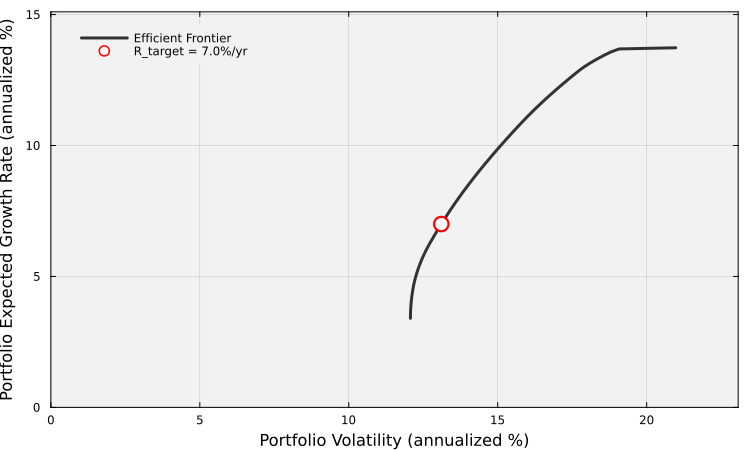


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Chosen portfolio: expected growth rate 7.0%/yr, volatility 13.11%/yr (finance convention)


In [5]:
minvar_result = let

    # --- Step 1: Build the SIM covariance matrix (units: 1/year²) ---
    Σ = build_sim_covariance(sim_estimates, σ_m);

    # --- Step 2: Long-only bounds and the QP ---
    bounds = hcat(zeros(N), fill(max_weight, N));
    problem = build(MyPortfolioAllocationProblem;
        μ = Eg_vec, Σ = Σ, bounds = bounds, R = R_target);

    # --- Step 3: Solve the minimum-variance QP at the target return ---
    mv = solve_minvariance(problem);

    # --- Step 3b: Solve the unconstrained-return QP for the global min-var point ---
    # This is the frontier's leftmost point. Sweeping R below this just repeats it.
    mv_problem_lo = build(MyPortfolioAllocationProblem;
        μ = Eg_vec, Σ = Σ, bounds = bounds, R = minimum(Eg_vec) - 1.0);
    mv_lo = solve_minvariance(mv_problem_lo);

    # --- Step 4: Sweep the target return to trace the efficient frontier ---
    # Start at the global min-var return so we trace only the upper (efficient)
    # branch, and use a dense grid for a smooth curve.
    R_grid = range(mv_lo.expected_return, 0.999 * maximum(Eg_vec), length = 150) |> collect;
    frontier_σ  = Float64[];
    frontier_Eg = Float64[];
    for R_i ∈ R_grid
        try
            prob_i = build(MyPortfolioAllocationProblem;
                μ = Eg_vec, Σ = Σ, bounds = bounds, R = R_i);
            sol = solve_minvariance(prob_i);
            σ_p  = sqrt(sol.variance) / sqrt(252) * 100;  # finance vol %/yr
            Eg_p = sol.expected_return * 100;             # %/yr
            push!(frontier_σ,  σ_p);
            push!(frontier_Eg, Eg_p);
        catch
            # infeasible, skip
        end
    end

    # Sort by σ so the line draws smoothly even if the solver returns points
    # that are not perfectly monotonic at tight tolerances.
    perm        = sortperm(frontier_σ);
    frontier_σ  = frontier_σ[perm];
    frontier_Eg = frontier_Eg[perm];

    # --- Step 5: Plot the efficient frontier and mark the chosen target ---
    chosen_σ  = sqrt(mv.variance) / sqrt(252) * 100;
    chosen_Eg = mv.expected_return * 100;
    max_σ  = maximum(frontier_σ);
    max_Eg = maximum(frontier_Eg);

    p = plot(frontier_σ, frontier_Eg,
        lw = 3, c = :gray20, label = "Efficient Frontier",
        xlabel = "Portfolio Volatility (annualized %)",
        ylabel = "Portfolio Expected Growth Rate (annualized %)",
        fontsize = 18,
        xlim = (0.0, 1.1 * max_σ),
        ylim = (0.0, 1.1 * max_Eg),
        size = (750, 450));
    scatter!(p, [chosen_σ], [chosen_Eg],
        marker = :circle, ms = 8, c = :white, msc = :red, msw = 2.5,
        label = "R_target = $(round(R_target*100, digits=1))%/yr");
    plot!(p, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent,
        legend = :topleft);

    display(p)
    println("Chosen portfolio: expected growth rate $(round(chosen_Eg, digits=2))%/yr, "
            * "volatility $(round(chosen_σ, digits=2))%/yr (finance convention)")

    mv
end;

The allocation we will forward-simulate is either the minimum-variance QP solution (default) or the `my_weights` override if set in Task 1. In the code block below, we resolve the final weight vector into `allocation_weights::Vector{Float64}` and display it as a table.

In [6]:
allocation_weights = let
    # --- Step 1: Resolve weights (QP default vs user override) ---
    w = isnothing(my_weights) ? minvar_result.weights : Float64.(my_weights);
    @assert length(w) == N "my_weights length must equal number of tickers"
    @assert isapprox(sum(w), 1.0; atol=1e-6) "my_weights must sum to 1"

    # --- Step 2: Display the weights as a table ---
    # Helper: round then clamp "-0.0" to "+0.0" for display -
    rnz(x, d) = begin
        r = round(x, digits=d);
        r == 0.0 ? 0.0 : r;
    end;
    df = DataFrame(
        "Ticker" => my_tickers,
        "Weight (%)" => [rnz(wi * 100, 2) for wi ∈ w]
    );
    println("Allocation to forward-simulate:")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    w
end;

Allocation to forward-simulate:
 -------- ------------
  Ticker   Weight (%) 
  String      Float64 
 -------- ------------
      VZ         0.96
       T          0.0
     MCD         13.1
      PG         20.0
      KO         0.58
     PEP        11.53
     WMT         20.0
     XOM          0.0
     CVX          0.0
     JPM          0.0
   BRK.B          0.0
     JNJ        10.82
     MRK         8.37
     HON          0.0
     UPS          0.0
    AAPL         0.05
    MSFT         3.49
     APD          0.0
     AMT          0.0
     NEE        11.09
 -------- ------------


___
## Task 2: Forward-Simulate the Allocation with Hybrid JumpHMM
In this task, we resolve realistic starting prices for each ticker, generate many synthetic futures via the hybrid SIM construction, and visualize a sample of the resulting wealth trajectories before scoring them quantitatively in Task 3.

> __What are we going to do?__
>
> Pull last-day closes from [the `MyCurrentPrices()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyCurrentPrices) so the simulated price paths begin at realistic levels, then call [the `generate_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_hybrid_scenario) to produce `n_paths` Monte Carlo futures composed of a JumpHMM market path, per-ticker HMM idiosyncratic draws (R²-preserving or variance-correcting), and Student-t copula rank-reordering. Visualize sample buy-and-hold wealth trajectories with the median across all paths overlaid.

The starting price for each ticker is the price each ticker has on the first simulated trading day, which determines how many shares the buy-and-hold engine purchases for the given allocation. In the code block below, we cache the last available real daily close from the testing OHLC dataset (Polygon S&P 500 data through 2025-12-31) into `start_prices::Dict{String,Float64}` and hand it to the hybrid scenario generator so the simulated price paths begin at realistic levels.

In [7]:
start_prices = let
    snap = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    sp = Dict{String, Float64}()
    for t ∈ my_tickers
        @assert haskey(snap_lookup, t) "Ticker $(t) not in MyCurrentPrices() snapshot"
        sp[t] = snap_lookup[t];
    end

    # --- Compute initial position: shares and dollar value per ticker ---
    # shares_i = (B₀ * w_i) / P_i  (fractional shares permitted)
    # dollar_i = shares_i * P_i = B₀ * w_i
    prices_vec  = [sp[t] for t ∈ my_tickers];
    dollars_vec = B₀ .* allocation_weights;
    shares_vec  = dollars_vec ./ prices_vec;

    println("Starting prices and initial position for forward simulation (from $(snap["source_label"])):")
    # Helper: round then clamp "-0.0" to "+0.0" for display -
    # (round() on small negatives returns -0.0, which prints with a minus sign)
    rnz(x, d) = begin
        r = round(x, digits=d);
        r == 0.0 ? 0.0 : r;
    end;

    df = DataFrame(
        "Ticker"         => my_tickers,
        "Price (\$)"     => [rnz(p, 2) for p ∈ prices_vec],
        "Weight (%)"     => [rnz(w * 100, 2) for w ∈ allocation_weights],
        "Shares"         => [rnz(s, 4) for s ∈ shares_vec],
        "Dollar Value"   => [rnz(d, 2) for d ∈ dollars_vec],
        "As of"          => [snap["last_dates"][findfirst(==(t), snap["tickers"])] for t ∈ my_tickers],
    );
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    println("\nTotal invested: \$$(round(sum(dollars_vec), digits=2))  (= B₀ = \$$(Int(B₀)))")

    sp
end;

Starting prices and initial position for forward simulation (from polygon-ohlc-testing-dataset):
 -------- ----------- ------------ --------- -------------- ---------------------
  Ticker   Price ($)   Weight (%)    Shares   Dollar Value                 As of 
  String     Float64      Float64   Float64        Float64                String 
 -------- ----------- ------------ --------- -------------- ---------------------
      VZ       40.73         0.96   23.6134         961.77   2025-12-31T05:00:00
       T       24.84          0.0       0.0            0.0   2025-12-31T05:00:00
     MCD      305.63         13.1   42.8775        13104.6   2025-12-31T05:00:00
      PG      143.31         20.0   139.558        20000.0   2025-12-31T05:00:00
      KO       69.91         0.58    8.3679          585.0   2025-12-31T05:00:00
     PEP      143.52        11.53   80.3348        11529.7   2025-12-31T05:00:00
     WMT      111.41         20.0   179.517        20000.0   2025-12-31T05:00:00
     XOM

With the starting prices resolved we run the forward Monte Carlo. Each path composes a JumpHMM market growth-rate path with a per-ticker HMM idiosyncratic draw, scales the innovations via either the R²-preserving branch (for tickers whose real-data $R^2 \geq 0.80$) or the marginal-preserving variance correction, and rank-reorders them through the Student-t copula.

> __Hybrid SIM Forward Construction:__
>
> For each of `n_paths` simulations and each ticker in the universe, we compose each ticker's growth rate via the decomposition:
>
> $$g_i(t) = \alpha_i + \beta_i\,g_{\mathrm{mkt}}(t) + \varepsilon_i(t)$$
>
> where:
>
> * $g_{\mathrm{mkt}}(t)$ is drawn from the [JumpHMM market surrogate](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyMarketSurrogateModel), a pre-trained model fitted on SPY with regime switching, volatility clustering, and jumps.
> * $\varepsilon_i(t)$ starts as a draw from the ticker's own HMM marginal in [the portfolio surrogate](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyPortfolioSurrogateModel), so it inherits the ticker's heavy tails and clustering. It is then scaled (variance-correcting if $R^2 < 0.80$, $R^2$-preserving otherwise) and copula rank-reordered so cross-sectional dependence matches the Student-t copula fitted on the real universe.
> * The composed growth rate is converted to a price via $S_{t+1} = S_t \exp(g_i(t)\,\Delta t)$.

[The `generate_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_hybrid_scenario) does all of the above in a single call and returns a [`MyBacktestScenario`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.MyBacktestScenario) whose `price_paths` field has shape `(n_paths, n_steps, N)`. In the code block below, we run the hybrid forward simulation and store the result in `scenario::MyBacktestScenario`.

In [8]:
scenario = let
    # --- Step 1: Load the surrogate models (cached on disk) ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();

    # --- Step 2: Generate the hybrid forward scenario ---
    scen = generate_hybrid_scenario(market_model, portfolio, sim_calibration, my_tickers;
        n_paths = n_paths,
        n_steps = n_steps,
        Δt      = Δt,
        start_prices = start_prices,
        label   = "Hybrid-SIM ($(n_steps)d)",
        seed    = 2026);

    # --- Step 3: Sanity check on the output shape ---
    println("scenario.price_paths shape: $(size(scen.price_paths)) "
            * "(n_paths × n_steps × N_tickers)")
    println("scenario.market_paths shape: $(size(scen.market_paths))")

    scen
end;

scenario.price_paths shape: (500, 252, 20) (n_paths × n_steps × N_tickers)
scenario.market_paths shape: (500, 252)


Before we run the scorecard it helps to visually confirm the scenario is reasonable. In the code block below, we compute the buy-and-hold wealth trajectory for 100 sampled paths using the allocation we resolved in Task 1 and overlay the median across all paths.

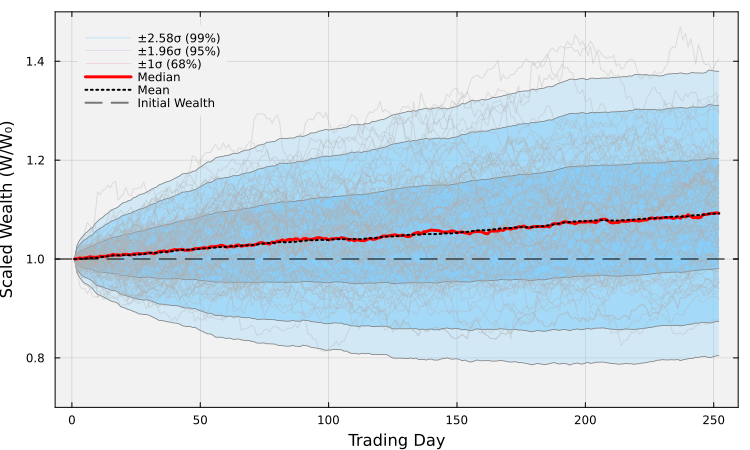

In [9]:
let
    # --- Step 1: Randomly sample paths for the spaghetti overlay ---
    Random.seed!(2027);
    sample_idx = rand(1:scenario.n_paths, 100);
    initial_wealth = B₀;

    # --- Step 2: Compute the full wealth matrix across ALL paths ---
    # wealth_all[t, p] = W(t) / W₀ for path p at time t
    N = length(my_tickers);
    wealth_all = zeros(scenario.n_steps, scenario.n_paths);
    for p ∈ 1:scenario.n_paths
        shares = [(B₀ * allocation_weights[k]) / scenario.price_paths[p, 1, k] for k in 1:N];
        for t ∈ 1:scenario.n_steps
            wealth_all[t, p] = (1/initial_wealth) * sum(shares[k] * scenario.price_paths[p, t, k] for k in 1:N);
        end
    end

    # --- Step 3: Median, mean, and std trajectory over ALL paths ---
    median_trajectory = [median(wealth_all[t, :]) for t ∈ 1:scenario.n_steps];
    mean_trajectory   = [mean(wealth_all[t, :])   for t ∈ 1:scenario.n_steps];
    std_trajectory    = [std(wealth_all[t, :])    for t ∈ 1:scenario.n_steps];

    # --- Step 4: Sampled paths for overlay (from Step 1 indices) ---
    wealth_sample = wealth_all[:, sample_idx];

    # --- Step 5: Plot ---
    # Gaussian quantile multipliers: 1.00σ ≈ 68%, 1.96σ ≈ 95%, 2.58σ ≈ 99% (two-sided).
    days = 1:scenario.n_steps;

    # Nested confidence ribbons (99% outermost, 95% middle, 68% innermost),
    # lighter alpha as bands widen. Plot outer first so inner bands paint over.
    p = plot(days, mean_trajectory;
        ribbon = 2.58 .* std_trajectory,
        fillalpha = 0.30, fillcolor = :lightskyblue,
        lw = 0, label = "±2.58σ (99%)",
        xlabel = "Trading Day",
        ylabel = "Scaled Wealth (W/W₀)",
        fontsize = 18,
        size = (750, 450));
    plot!(p, days, mean_trajectory .+ 2.58 .* std_trajectory;
        lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory .- 2.58 .* std_trajectory;
        lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory;
        ribbon = 1.96 .* std_trajectory,
        fillalpha = 0.60, fillcolor = :lightskyblue,
        lw = 0, label = "±1.96σ (95%)");
    plot!(p, days, mean_trajectory .+ 1.96 .* std_trajectory;
        lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory .- 1.96 .* std_trajectory;
        lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory;
        ribbon = 1.00 .* std_trajectory,
        fillalpha = 0.95, fillcolor = :lightskyblue,
        lw = 0, label = "±1σ (68%)");
    plot!(p, days, mean_trajectory .+ 1.00 .* std_trajectory;
        lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory .- 1.00 .* std_trajectory;
        lw = 0.8, c = :gray50, label = "");

    # Spaghetti overlay of sampled paths
    plot!(p, days, wealth_sample;
        lw = 1, c = :gray69, alpha = 0.35, label = "");

    # Median and mean lines
    plot!(p, days, median_trajectory;
        lw = 3, c = :red, label = "Median");
    plot!(p, days, mean_trajectory;
        lw = 2, ls = :dot, c = :black, label = "Mean");

    # Break-even reference
    hline!(p, [1.0];
        lw = 2, ls = :dash, c = :black, alpha = 0.5, label = "Initial Wealth");

    plot!(p, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent,
        legend = :topleft,
        ylims = (0.70, 1.50));
    display(p)
end;

___
## Task 3: Score the Distribution and Hand Off
In this task, we hold the allocation buy-and-hold across every simulated path, summarize the resulting distribution of outcomes (terminal wealth, max drawdown, Sharpe ratio, fail rate), visualize the spread with histograms, and persist the allocation plus scorecard to disk so downstream stress-test notebooks can load it directly.

> __Scorecard:__
>
> A scorecard turns thousands of simulated futures into a handful of distribution-level numbers.
>
> * __Terminal wealth distribution:__ The median $W_T$ is summarized together with $P_{10}$ (a pessimistic-tail benchmark) and $P_{90}$ (an optimistic-tail benchmark); the width $P_{90} - P_{10}$ is a proxy for the spread of plausible futures. Here $P_q$ denotes the $q$-th percentile: the value below which fraction $q/100$ of paths fall.
> * __Path-level risk summaries:__ The **median max drawdown** is the median over per-path peak-to-trough drawdowns $\max_{s \leq t}\{(W^{(p)}_s - W^{(p)}_t)/W^{(p)}_s\}$, and the **median Sharpe ratio** is the median over per-path Sharpes $(\bar{g}^{(p)} - g_f)/\hat{\sigma}^{(p)}$. Both collapse thousands of path-level numbers into one representative value.
> * __Failure rates against the right benchmark:__ The nominal **fail rate** $P[W_T < B_0]$ answers the blunt "chance I lose money" question, while the **NPV-fail rate** $P[\text{NPV} < 0]$ asks whether the portfolio beat the risk-free baseline. The per-path NPV is $\text{NPV}^{(p)}(g_f, T) = -B_0 + W_{\mathcal{P}}^{(p)}(T)\,e^{-g_f T}$; for the formal definition see [the Portfolio NPV section of the Session 1 lecture](eCornell-AI-Finance-S1-Lecture-StressTestingMinVariancePortfolios-May-2026.ipynb).
>
> We compute all of these with [the `backtest_buyhold(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_buyhold), passing `offset = 1` because the buy lands on day 1.

In the code block below, we run the buy-and-hold engine and store the result in `result::MyBacktestResult`.

In [10]:
result = let
    # --- Step 1: Run buy-and-hold across every path ---
    r = backtest_buyhold(scenario, my_tickers;
        B₀      = B₀,
        offset  = 1,                      # buy on day 1
        weights = allocation_weights);

    # --- Step 2: Per-path NPV against the continuously compounded risk-free baseline ---
    # NPV(g_f, T) = -B₀ + W_T · e^(-g_f · T)   (in today's dollars)
    T_years = scenario.n_steps / 252;
    npv     = r.final_wealth .* exp(-g_f * T_years) .- B₀;

    # --- Step 3: Summarize the terminal wealth / drawdown / Sharpe / NPV distributions ---
    scorecard = DataFrame(
        "Metric" => [
            "Median terminal wealth",
            "P10 terminal wealth",
            "P90 terminal wealth",
            "Median max drawdown",
            "Median Sharpe ratio",
            "Fail rate P[W_T < B₀]",
            "Median NPV vs risk-free",
            "NPV-fail rate P[NPV < 0]"
        ],
        "Units" => [
            "W_T / B₀",
            "W_T / B₀",
            "W_T / B₀",
            "%",
            "dimensionless",
            "%",
            "USD",
            "%"
        ],
        "Value" => [
            round(median(r.final_wealth) / B₀, digits=3),
            round(quantile(r.final_wealth, 0.10) / B₀, digits=3),
            round(quantile(r.final_wealth, 0.90) / B₀, digits=3),
            round(median(r.max_drawdowns) * 100, digits=2),
            round(median(r.sharpe_ratios), digits=3),
            round(mean(r.final_wealth .< B₀) * 100, digits=1),
            round(median(npv), digits=0),
            round(mean(npv .< 0) * 100, digits=1)
        ]
    );

    println("Buy-and-hold scorecard over $(scenario.n_paths) paths, $(scenario.n_steps)-day horizon:")
    pretty_table(scorecard; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    r
end;

Buy-and-hold scorecard over 500 paths, 252-day horizon:
 -------------------------- --------------- ---------
                    Metric           Units     Value 
                    String          String   Float64 
 -------------------------- --------------- ---------
    Median terminal wealth        W_T / B₀     1.093
       P10 terminal wealth        W_T / B₀     0.951
       P90 terminal wealth        W_T / B₀     1.228
       Median max drawdown               %     12.47
       Median Sharpe ratio   dimensionless     0.597
     Fail rate P[W_T < B₀]               %      21.8
   Median NPV vs risk-free             USD    4447.0
  NPV-fail rate P[NPV < 0]               %      34.8
 -------------------------- --------------- ---------


In the code block below, we plot histograms of the distributions across paths with the median marked on each.

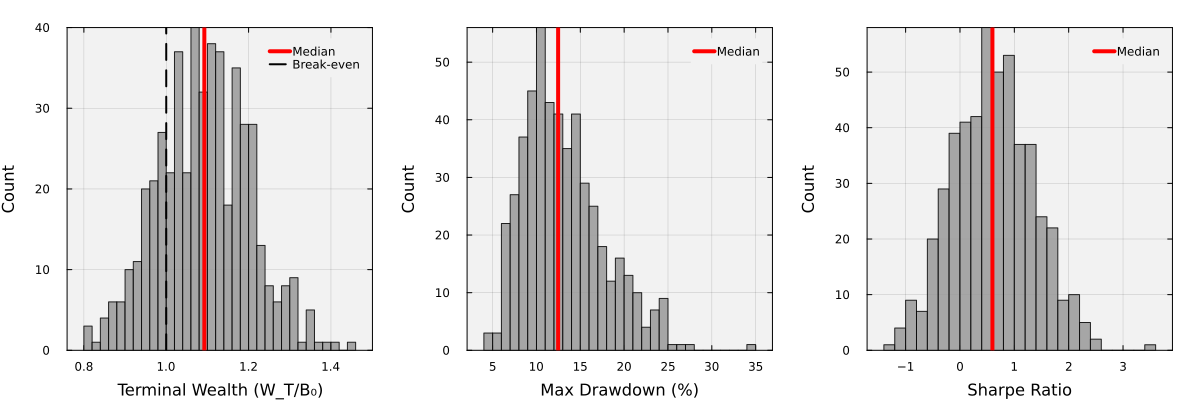

In [11]:
let
    scaled_wealth = result.final_wealth ./ B₀;
    median_wealth = median(scaled_wealth);
    median_dd     = median(result.max_drawdowns);
    median_sharpe = median(result.sharpe_ratios);

    # --- Panel 1: Scaled terminal wealth ---
    p1 = histogram(scaled_wealth, bins = 40, alpha = 0.85, color = :gray60,
        xlabel = "Terminal Wealth (W_T/B₀)", ylabel = "Count",
        fontsize = 18, label = "");
    vline!(p1, [median_wealth], lw = 4, c = :red, label = "Median");
    vline!(p1, [1.0], lw = 2, ls = :dash, c = :black, label = "Break-even");
    plot!(p1, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent);

    # --- Panel 2: Max drawdown ---
    p2 = histogram(result.max_drawdowns .* 100, bins = 40, alpha = 0.85, color = :gray60,
        xlabel = "Max Drawdown (%)", ylabel = "Count",
        fontsize = 18, label = "");
    vline!(p2, [median_dd * 100], lw = 4, c = :red, label = "Median");
    plot!(p2, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent);

    # --- Panel 3: Sharpe ratio ---
    p3 = histogram(result.sharpe_ratios, bins = 40, alpha = 0.85, color = :gray60,
        xlabel = "Sharpe Ratio", ylabel = "Count",
        fontsize = 18, label = "");
    vline!(p3, [median_sharpe], lw = 4, c = :red, label = "Median");
    plot!(p3, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent);

    plot(p1, p2, p3, layout = (1, 3), size = (1200, 400), margin = 5Plots.mm)
end

Finally we persist the allocation, SIM parameters, and the scorecard arrays to disk. The next notebook in this sequence (Stress-Test) will load this file directly instead of re-solving the QP. In the code block below, we save the handoff file using [the `save_results(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.save_results).

In [12]:
let
    save_path = joinpath(_PATH_TO_DATA, "minvar-allocation.jld2");
    T_years = scenario.n_steps / 252;
    npv     = result.final_wealth .* exp(-g_f * T_years) .- B₀;
    save_results(save_path, Dict(
        "my_tickers"         => my_tickers,
        "allocation_weights" => allocation_weights,
        "sim_estimates"      => sim_estimates,
        "sigma_market"       => σ_m,
        "R_target"           => R_target,
        "g_f"                => g_f,                              # propagated to StressTest
        "r_f"                => g_f,                              # backward-compatible alias
        "cash_fraction"      => 0.0,                              # RA is fully invested
        "final_wealth"       => result.final_wealth,
        "max_drawdowns"      => result.max_drawdowns,
        "sharpe_ratios"      => result.sharpe_ratios,
        "npv"                => npv,                              # NPV(g_f, T) per path
    ));

    println("Saved minimum-variance allocation to: $(save_path)")
    println("  $(length(my_tickers)) tickers, R_target = $(round(R_target*100, digits=1))%/yr")
    println("  $(length(result.final_wealth)) buy-and-hold scorecard paths")
end;

Saved minimum-variance allocation to: /Users/jeffreyvarner/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-1/data/minvar-allocation.jld2
  20 tickers, R_target = 7.0%/yr
  500 buy-and-hold scorecard paths


___
## Summary
This example assembled a minimum-variance portfolio on a user-chosen ticker subset from cached SIM calibration, traced the efficient frontier, and forward-simulated the chosen allocation with the hybrid JumpHMM construction to produce a distributional scorecard across buy-and-hold paths.

> __Key Takeaways:__
>
> * __Calibrated SIM closes the synthetic-reality gap:__ Real-data regression parameters give the optimization problem cross-sectional structure that students can map onto familiar ticker names. The covariance matrix and the forward simulator share the same market volatility scaffolding, so the point chosen on the efficient frontier really is the allocation being stress-tested.
> * __Hybrid forward simulation preserves tails and regimes:__ Composing a JumpHMM market path with per-ticker HMM marginals and a Student-t copula injects fat tails, regime switching, and cross-sectional dependence that a Gaussian simulation cannot match. The same scenario infrastructure is reused in Session 3, so the training work here transfers directly.
> * __Scorecards replace point estimates:__ Median terminal wealth, percentile spreads, maximum drawdown, Sharpe ratio, and failure rates across many synthetic futures turn a single allocation into a full risk profile. This distributional lens is the framing carried forward into the Stress-Test example and every downstream session.

The saved parameter file is used by downstream notebooks for preference weight computation and covariance construction.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.
___